# Cost Prediction Regression

## Notebook Objective

This notebook builds a baseline multiple linear regression model to predict monthly member cost.

The goal is to create a simple, interpretable benchmark model before testing more advanced cost prediction methods. Because the target variable is continuous, this is a regression problem, not a classification problem.

The main focus is to evaluate how well basic member demographics, risk, engagement, access, and utilization features can explain variation in monthly cost.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Load Processed Dataset

This notebook uses the analysis-ready dataset created in the feature engineering notebook.

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv") # Load the dataset
df.head() # Display the first few rows of the dataset


,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,...,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,...,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,...,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,...,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,...,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,...,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


## 3. Define Target and Features

### Timing Note

In this synthetic dataset, ED visits and inpatient admissions are generated before monthly cost and are valid predictors within the data-generation process. In a real healthcare cost prediction model, utilization predictors should usually be defined using a prior measurement window, such as prior-year ED visits and admissions, to avoid same-period leakage. 

In [3]:
target = "monthly_cost"  # Define the regression target variable

drop_cols = [
    "member_id",
    target,
    "high_cost_member",
    "awv_completed",

    # Drop full-dataset quartile / grouped features
    "engagement_group",
    "sdoh_risk_group",
    "age_group",
    "chronic_burden_group",
    "pcp_status",
    "prior_awv_group",

    # Drop redundant utilization features
    "total_acute_visits",
    "acute_utilization_group",
    "has_acute_utilization",

    # Drop duplicate prior AWV representation
    "prior_awv_count"
]

X = df.drop(columns=drop_cols)  # Create predictor dataset after removing identifier, target, and leakage-prone columns
y = df[target]  # Store monthly cost as the regression target

## Feature Selection Explanation

The predictor set was intentionally restricted to avoid leakage and improve interpretability.

`high_cost_member` was excluded because it is directly derived from `monthly_cost`, the target variable. Including it would give the model information about the answer.

`awv_completed` was excluded to keep this baseline model focused on member risk, access, engagement, and utilization rather than using a same-year outcome-style variable.

Grouped features such as `age_group`, `engagement_group`, and `sdoh_risk_group` were excluded because the raw numeric variables are already included. Keeping both raw and grouped versions would make coefficient interpretation less clean.

`total_acute_visits`, `acute_utilization_group`, and `has_acute_utilization` were excluded because `ed_visits` and `ip_admits` are already included separately.

## 4. Prepare Modeling Data

In [4]:
categorical_cols = X.select_dtypes(
    include=["object", "string", "category", "bool"]  # Select categorical/text-like predictors
).columns.tolist()  # Store categorical column names as a list

numeric_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]  # Select numeric predictors
).columns.tolist()  # Store numeric column names as a list

print("Categorical columns:", categorical_cols)
print("Numeric Columns:", numeric_cols)



Categorical columns: ['gender', 'region', 'plan_type']
Numeric Columns: ['age', 'sdoh_risk_score', 'chronic_condition_count', 'engagement_score', 'pcp_attributed_24mo', 'prior_awv_rate', 'ed_visits', 'ip_admits']


In [5]:
# Build the preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_cols  # One-hot encode categorical predictors
        ),
        (
            "num",
            StandardScaler(),
            numeric_cols  # Standardize numeric predictors
        )
    ]
)


## Preprocessing Explanation

The model uses a `ColumnTransformer` so categorical and numeric predictors can be processed differently.

Categorical predictors are one-hot encoded because Linear Regression cannot directly use text categories such as gender, region, or plan type.

Numeric predictors are standardized so they are placed on a comparable scale. This is especially useful when reviewing coefficients, because variables such as age, SDOH score, ED visits, and inpatient admissions use different units.

The preprocessing steps are placed inside a scikit-learn `Pipeline` so transformations are learned from the training data and then applied consistently to the test data.

## 5. Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split the data into training and testing sets

# No Stratify =  y because stratify is usually for classification targets & monthly_cost is continuous.

## 6. Build Baseline Linear Regression Model

In [7]:
lr_model = Pipeline(steps = [ ("preprocessor", preprocessor) , ("model", LinearRegression()) ]) # Create a pipeline that combines the preprocessor and the linear regression model

lr_model.fit(X_train, y_train) # Fit the model to the training data


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 7. Evaluate Regression Performance 

In [8]:
# Make Predictions

y_pred = lr_model.predict(X_test) # Predict the target variable for the test set

# Calculate Metrics

mae = mean_absolute_error(y_test, y_pred) # Calculate Mean Absolute Error
mse = mean_squared_error(y_test, y_pred) # Calculate Mean Squared Error
rmse = np.sqrt(mse) # Calculate Root Mean Squared Error
r2 = r2_score(y_test, y_pred) # Calculate R-squared

print(f"MAE: ${mae:,.2f}")
print(f"MSE: {mse:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²: {r2:.3f}")






MAE: $404.20
MSE: 428,067.82
RMSE: $654.27
R²: 0.764


## Metric Interpretation

The model has an MAE of about `$404`, meaning the average absolute prediction error is approximately `$404` per member per month.

The RMSE is about `$654`, which is noticeably higher than the MAE. This suggests that the model has some large prediction errors, likely among high-cost members or members with unusual acute events.

The R² value is about `0.764`, meaning the model explains about 76.4% of the variation in monthly cost in the test set.

R² should not be described as model accuracy. It measures explained variance, not the percentage of predictions that are correct.

## 8. Interpret Regression Coefficients

In [9]:
ohe = lr_model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(categorical_cols) # Get the names of the encoded categorical features
all_feature_names = list(encoded_cat_features) + numeric_cols # Combine encoded categorical feature names with numeric feature names

# Get Coefficients

coefficients = lr_model.named_steps["model"].coef_ # Get the coefficients from the linear regression model
coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients
})

coef_df["absolute_coefficient"] = coef_df["Coefficient"].abs() # Calculate the absolute value of the coefficients
coef_df = coef_df.sort_values(by="absolute_coefficient", ascending=False) # Sort the coefficients by absolute value

coef_df.head(15)

,Feature,Coefficient,absolute_coefficient
7,chronic_condition_count,685.326198,685.326198
12,ip_admits,579.390145,579.390145
3,plan_type_Medicaid,-545.995977,545.995977
4,plan_type_Medicare Advantage,-417.503901,417.503901
11,ed_visits,261.574043,261.574043
2,region_Urban,-105.978163,105.978163
5,age,63.194242,63.194242
8,engagement_score,-62.284947,62.284947
1,region_Suburban,-48.937854,48.937854
9,pcp_attributed_24mo,-39.571305,39.571305


## Coefficient Interpretation

The largest positive coefficients are associated with chronic condition count, inpatient admissions, and ED visits. This means these features are associated with higher predicted monthly cost, holding other included variables constant.

Plan type coefficients are dummy-variable coefficients. They must be interpreted relative to the omitted reference category from one-hot encoding.

Because numeric features were standardized, numeric coefficients represent the expected change in predicted monthly cost for a one-standard-deviation increase in the feature.

These coefficients are conditional model associations, not causal effects.

## 9. Review Predictions Errors

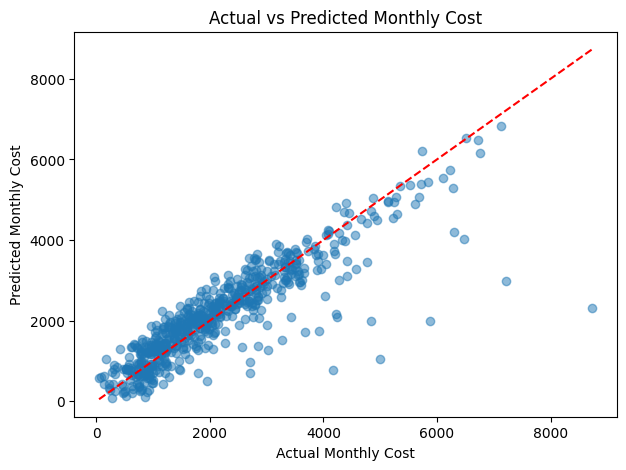

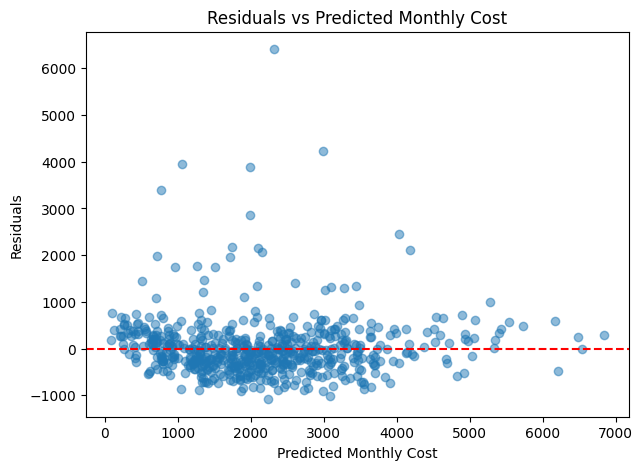

,actual_monthly_cost,predicted_monthly_cost,residual,absolute_error
415,8734.22,2325.456921,6408.763079,6408.763079
184,7218.17,2985.419853,4232.750147,4232.750147
8,5004.13,1058.680046,3945.449954,3945.449954
160,5879.72,1987.915344,3891.804656,3891.804656
225,4163.09,765.366597,3397.723403,3397.723403
102,4841.47,1983.789614,2857.680386,2857.680386
188,6484.28,4032.577620,2451.702380,2451.702380
116,3920.62,1736.642388,2183.977612,2183.977612
104,4247.30,2097.369699,2149.930301,2149.930301
578,6296.58,4188.838085,2107.741915,2107.741915


In [10]:
# Actual vs Predicted Scatter Plot

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.5) # Create a scatter plot of actual vs predicted values
plt.xlabel("Actual Monthly Cost") # Label for x-axis
plt.ylabel("Predicted Monthly Cost") # Label for y-axis
plt.title("Actual vs Predicted Monthly Cost") # Title for the plot
min_cost = min(y_test.min(), y_pred.min())
max_cost = max(y_test.max(), y_pred.max())

plt.plot([min_cost, max_cost], [min_cost, max_cost], "r--")
plt.show()

# Residuals Plot
residuals = y_test - y_pred # Calculate residuals
plt.figure(figsize=(7,5))
plt.axhline(0, color='red', linestyle='--') # Add a horizontal line at y=0
plt.scatter(y_pred, residuals, alpha=0.5) # Create a scatter plot of predicted values vs residuals
plt.xlabel("Predicted Monthly Cost") # Label for x-axis
plt.ylabel("Residuals") # Label for y-axis
plt.title("Residuals vs Predicted Monthly Cost") # Title for the plot
plt.show()

# Compare a few predictions 

comparison_df = pd.DataFrame({
    "actual_monthly_cost": y_test.values,  # Actual monthly cost values
    "predicted_monthly_cost": y_pred,  # Predicted monthly cost values
    "residual": y_test.values - y_pred,  # Actual minus predicted
    "absolute_error": np.abs(y_test.values - y_pred)  # Error size regardless of direction
})

comparison_df.sort_values(
    "absolute_error",  # Sort by largest prediction error
    ascending=False  # Show largest errors first
).head(10)



## Coefficient Interpretation

The largest positive coefficients are associated with chronic condition count, inpatient admissions, and ED visits. This means these features are associated with higher predicted monthly cost, holding other included variables constant.

Plan type coefficients are dummy-variable coefficients. They must be interpreted relative to the omitted reference category from one-hot encoding.

Because numeric features were standardized, numeric coefficients represent the expected change in predicted monthly cost for a one-standard-deviation increase in the feature.

These coefficients are conditional model associations, not causal effects.

## 10. Findings

The purpose of this notebook was to build a baseline multiple linear regression model to predict monthly member cost.

The target variable was `monthly_cost`.

The predictor set excluded `member_id`, `high_cost_member`, and `awv_completed`. `member_id` was excluded because it is only an identifier. `high_cost_member` was excluded because it is derived from the cost target and would create target leakage. `awv_completed` was excluded to keep the baseline cost prediction model focused on member characteristics, risk, access, and utilization rather than using the AWV outcome as a predictor.

Categorical variables were one-hot encoded, and numeric variables were standardized.

Model performance was evaluated using MAE, MSE, RMSE, and R². MAE shows the average absolute prediction error, while RMSE penalizes larger errors more heavily. R² shows the share of cost variation explained by the model.

Regression coefficients describe conditional associations with predicted monthly cost, holding other included variables constant. Because numeric predictors were standardized, numeric coefficients represent the expected change in predicted monthly cost for a one-standard-deviation increase in the predictor. Dummy-variable coefficients represent differences relative to the omitted reference category.

The residual plots were used to check whether prediction errors were randomly scattered or whether the model showed systematic error patterns, such as underprediction among high-cost members.

Because this is synthetic data, the observed relationships reflect the assumptions built into the data-generation process and should not be interpreted as real-world causal evidence.